In [16]:
# Import libraries
import numpy as np
import pandas as pd
import rasterio as rio
from rasterio.mask import mask
import xarray as xr
import rioxarray
import geopandas as gpd
from shapely.geometry import mapping
import matplotlib.pyplot as plt
import os

## August 2025 (No fire scenario)

**Read NO2 imported from GEE: median, std and n pixels**

In [17]:
# Read 2025 (No fire) NO2 data for study area
band_path01 = 'data_gee/NO2tropMed_0225_float_study_area.tif' # Median data
ds_path01 = xr.open_dataset(band_path01, engine="rasterio", masked=True) # Setting masked=True converts NoData values automatically to NaN

band_path02 = 'data_gee/NO2tropStd_0225_float_study_area.tif'
ds_path02 = xr.open_dataset(band_path02, engine="rasterio", masked=True)

band_path03 = 'data_gee/NO2tropN_0225_float_study_area.tif'
ds_path03 = xr.open_dataset(band_path03, engine="rasterio", masked=True)



**Plot Raw data**

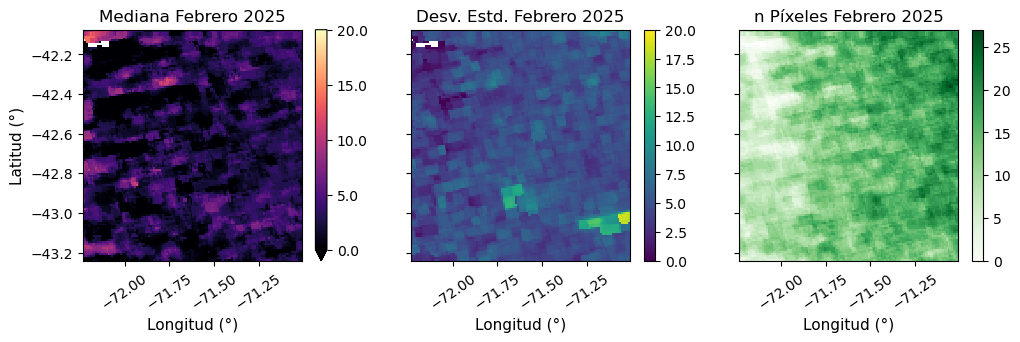

In [50]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

ds_path01.band_data.plot(ax=ax[0], vmin=0, vmax=20, cmap='magma', 
    cbar_kwargs={"label": None, "format": '%.1f'})
ax[0].set_title('Mediana Febrero 2025')
ax[0].set_ylabel('Latitud (°)', size=11)
ax[0].set_xlabel('Longitud (°)', size=11)
ax[0].tick_params(axis='x', labelrotation=35)
ds_path02.band_data.plot(ax=ax[1], vmin=0, vmax=20, cmap='viridis', 
    cbar_kwargs={"label": None, "format": '%.1f'})
ax[1].set_title('Desv. Estd. Febrero 2025')
ax[1].set_ylabel(None)
ax[1].set_xlabel('Longitud (°)', size=11)
ax[1].tick_params(axis='x', labelrotation=35)
ds_path03.band_data.plot(ax=ax[2], vmin=0, cmap='Greens', cbar_kwargs={"label": None})
ax[2].set_title('n Píxeles Febrero 2025')
ax[2].set_ylabel(None)
ax[2].set_xlabel('Longitud (°)', size=11)
ax[2].tick_params(axis='x', labelrotation=35)

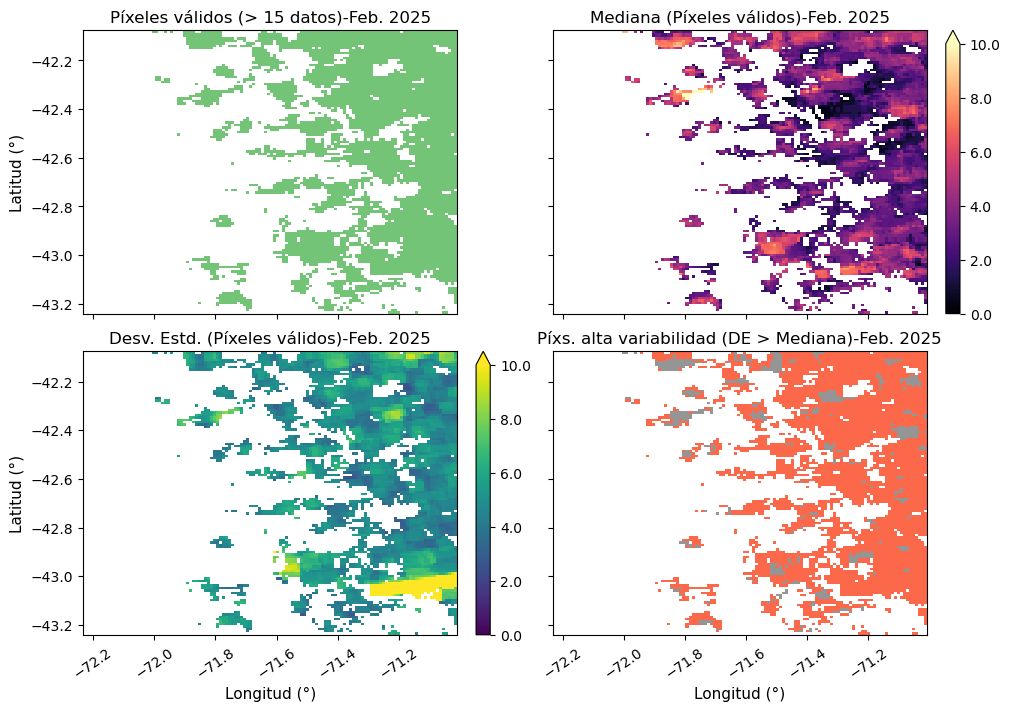

In [108]:
fig, ax = plt.subplots(2, 2, figsize=(10, 7), 
    sharey=True, sharex=True, 
    constrained_layout=True)

# Define a mask
mask_01 = ds_path03.band_data > 15 # n count pixels greater than 15 (from 30)

## Pixels with > 15 valid data
n_val_01 = xr.where(mask_01, 1, 0).where(mask_01)
n_val_01.plot(ax=ax[0, 0], add_colorbar=False, cmap='Greens')
ax[0, 0].set_title('Píxeles válidos (> 15 datos)-Feb. 2025')
ax[0, 0].set_ylabel('Latitud (°)', size=11)
ax[0, 0].set_xlabel(None)

## Median values for valid pixels
med_val_01 = ds_path01.band_data.where(mask_01)
med_val_01.plot(ax=ax[0, 1], cmap='magma', vmin=0, vmax=10, 
    cbar_kwargs={"label": None, "format": '%.1f'})
ax[0, 1].set_title('Mediana (Píxeles válidos)-Feb. 2025')
ax[0, 1].set_ylabel(None)
ax[0, 1].set_xlabel(None)

##-
std_val_01 = ds_path02.band_data.where(mask_01)
std_val_01.plot(ax=ax[1, 0], cmap='viridis', vmin=0, vmax=10, 
    cbar_kwargs={"label": None, "format": '%.1f'})
ax[1, 0].set_title('Desv. Estd. (Píxeles válidos)-Feb. 2025')
ax[1, 0].set_ylabel('Latitud (°)', size=11)
ax[1, 0].set_xlabel('Longitud (°)', size=11)
ax[1, 0].tick_params(axis='x', labelrotation=35)
##-
stdMed_val_01 = xr.where(std_val_01>med_val_01, 1, np.nan)
n_val_01.plot(ax=ax[1, 1], add_colorbar=False, cmap='Grays') # add background layer for pixels with std < median
stdMed_val_01.plot(ax=ax[1, 1], add_colorbar=False, cmap='Reds')
ax[1, 1].set_title('Píxs. alta variabilidad (DE > Mediana)-Feb. 2025')
ax[1, 1].set_ylabel(None)
ax[1, 1].set_xlabel('Longitud (°)', size=11)
ax[1, 1].tick_params(axis='x', labelrotation=35)

# NOTA
# mediana > sd ==> poca variabilidad
# mediana < sd ==> alta variabilidad

## January 2026 (Fire scenario)

**Read data downloaded from GEE**

In [10]:
# Read 2026 (fire) NO2 mean data for study area
band_path04 = 'data_gee/NO2tropMed_0126_float_study_area.tif' # Median data
ds_path04 = xr.open_dataset(band_path04, engine="rasterio", masked=True) # Setting masked=True converts NoData values automatically to NaN

band_path05 = 'data_gee/NO2tropStd_0126_float_study_area.tif'
ds_path05 = xr.open_dataset(band_path05, engine="rasterio", masked=True)

band_path06 = 'data_gee/NO2tropN_0126_float_study_area.tif'
ds_path06 = xr.open_dataset(band_path06, engine="rasterio", masked=True)

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10, 7), sharey=True, sharex=True)

np.float32(34.0)

'\nds_path03.band_data.where(ds_path03.band_data > 20).plot(ax=ax[1, 0], vmin=8)\nxr.where(ds_path02.band_data > ds_path01.band_data, 1, 0).where(ds_path03.band_data > 20).plot(ax=ax[1, 1])\n'

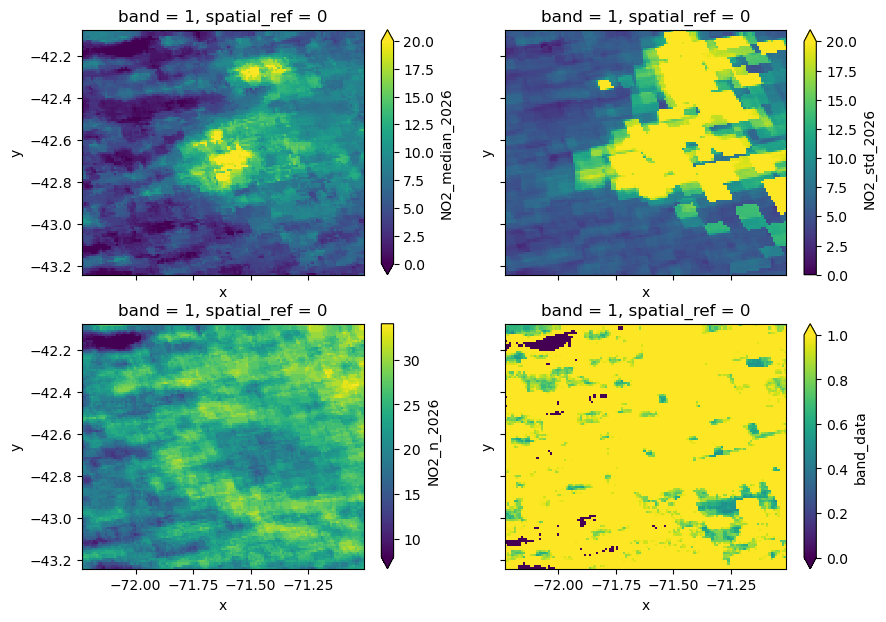

In [30]:
fig, ax = plt.subplots(2, 2, figsize=(10, 7), sharey=True, sharex=True)


ds_path04.band_data.plot(ax=ax[0, 0], vmin=0, vmax=20)
ds_path05.band_data.plot(ax=ax[0, 1], vmin=0, vmax=20)
ds_path06.band_data.plot(ax=ax[1, 0], vmin=8)
#xr.where(ds_path05.band_data/ds_path04.band_data>0.5, 1, 0).where(ds_path06.band_data > 20).plot(ax=ax[1, 1])
(ds_path05.band_data/ds_path04.band_data).plot(ax=ax[1, 1], vmin=0, vmax=1)


'''
ds_path03.band_data.where(ds_path03.band_data > 20).plot(ax=ax[1, 0], vmin=8)
xr.where(ds_path02.band_data > ds_path01.band_data, 1, 0).where(ds_path03.band_data > 20).plot(ax=ax[1, 1])
'''
#(ds_path06.band_data).plot(ax=ax[1, 0], vmin=8)

## Aug 2025 vs Jan 2026 difference

In [33]:
diff_2525 = (ds_path04.band_data-ds_path01.band_data)/ds_path01.band_data

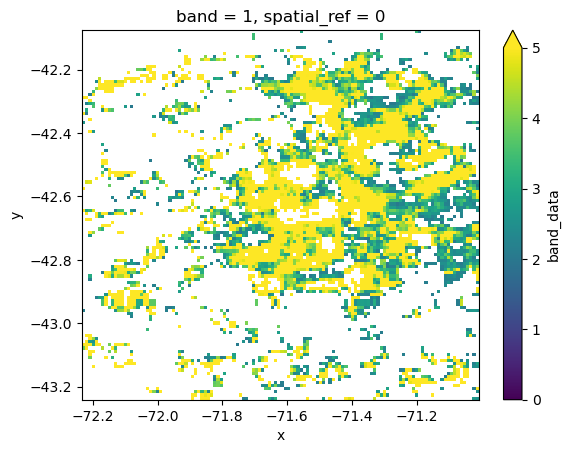

In [41]:
diff_2525.where(diff_2525 > 2).plot(vmin=0, vmax=5)